In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Studies by country pie chart

In [2]:
Dataset = pd.read_excel('Dataset_final.xlsx', 'Combined_info')
# Dataset.set_index('Study.Identifier')

In [8]:
data = Dataset.Country.value_counts(ascending=False).to_list()
label = Dataset.Country.value_counts(ascending=False).index.to_list()
labels = []

for num in range(len(data)):
    country = label[num]
    country_count = data[num]
    country_percentage = round(data[num]/sum(data)*100, 2)
    country_label = country + "\n" + str(country_count) + " ("+str(country_percentage) + "%)"
    labels.append(country_label)

In [7]:
# plt.style.available

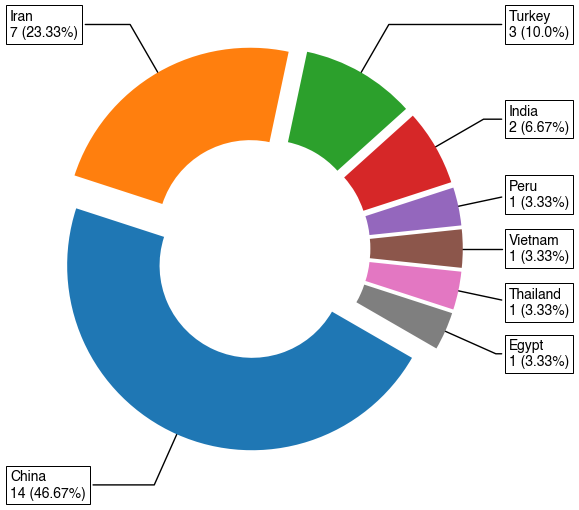

In [40]:
fig, ax = plt.subplots(figsize=(7, 6), subplot_kw=dict(aspect="equal"))
wedges, texts = ax.pie(data, wedgeprops=dict(width=0.5), startangle=-30, 
    explode=[0.1]*8, counterclock = False)

bbox_props = dict(boxstyle="square,pad=0.3", fc="w", ec="k", lw=0.72)
kw = dict(arrowprops=dict(arrowstyle="-"),
          bbox=bbox_props, zorder=0, va="center")

for i, p in enumerate(wedges):
    ang = (p.theta2 - p.theta1)/2. + p.theta1
    y = np.sin(np.deg2rad(ang))
    x = np.cos(np.deg2rad(ang))
    horizontalalignment = {-1: "right", 1: "left"}[int(np.sign(x))]
    connectionstyle = "angle,angleA=0,angleB={}".format(ang)
    kw["arrowprops"].update({"connectionstyle": connectionstyle, "color": "black"})
    ax.annotate(labels[i], xy=(x, y), xytext=(1.35*np.sign(x), 1.4*y), fontname="Helvetica", fontsize = 10, **kw)

plt.savefig("studies by country.pdf")

# Effect measure summary

In [47]:
Dataset = pd.read_excel('Dataset_final.xlsx', 'Combined').set_index('Study.Identifier')
Effect_measure_summary = Dataset[['Effect.measure', 'Measurement.method', 'Measurement.type', 'Pre_mean',
       'Pre_N', 'Pre_SD', 'Post_mean', 'Post_N', 'Post_SD', '95CI_lower',
       '95CI_upper', 'Duration', 'Measurement points (days from start)',
       'Treatment duration (days from start)']].reset_index()

In [48]:
Effect_measure_summary

,Study.Identifier,Effect.measure,Measurement.method,Measurement.type,Pre_mean,Pre_N,Pre_SD,Post_mean,Post_N,Post_SD,95CI_lower,95CI_upper,Duration,Measurement points (days from start),Treatment duration (days from start)
0,Uyar 2019,Caregiver anxiety,BAI,Raw,10.06,30.0,8.89,6.18,26.0,7.26,NaN,NaN,16 weeks,112.0,112
1,Uyar 2019,Caregiver anxiety,BAI,Raw,12.23,31.0,8.05,15.47,28.0,9.28,NaN,NaN,16 weeks,112.0,112
2,Zarepour 2020,Caregiver anxiety,Spielberger questionnaires,Raw,74.11,35.0,4.73,70.51,NaN,3.78,NaN,NaN,1 month post intervention,58.0,28
3,Zarepour 2020,Caregiver anxiety,Spielberger questionnaires,Raw,75.63,35.0,3.08,76.45,NaN,3.45,NaN,NaN,1 month post intervention,58.0,28
4,Zarepour 2020,Caregiver anxiety,Spielberger questionnaires,Raw,74.11,35.0,4.73,70.31,NaN,3.78,NaN,NaN,3 months post intervention,118.0,28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
131,SUN 2010,Patient quality of life,SF36,Raw,448.10,19.0,132.40,570.10,19.0,141.90,NaN,NaN,12 months post-intervention,365.0,365
132,Uyar 2019,Patient quality of life,QoL-Ada,Raw,31.18,22.0,6.14,31.79,17.0,5.41,NaN,NaN,16 weeks,112.0,112
133,Uyar 2019,Patient quality of life,QoL-Ada,Raw,33.29,20.0,4.96,32.39,17.0,4.33,NaN,NaN,16 weeks,112.0,112
134,ZHAO 2010,Patient quality of life,SF36,Raw,431.40,25.0,126.50,524.70,25.0,128.40,NaN,NaN,12 months,365.0,365
